#  Business Intelligence — E-Sitrana
**Projet :** Système d'Information Médical E-Sitrana  
**Date d'analyse :** 01/05/2026  
**Objectif :** Mise en place d'un Data Warehouse, processus ETL et tableaux de bord décisionnels

---

## Plan du notebook
1. **Import & Configuration**
2. **EXTRACTION : Chargement des données sources**
3. **TRANSFORMATION : Nettoyage & Modélisation en Étoile**
4. **CHARGEMENT : Construction du Data Warehouse**
5. **ANALYSE & KPIs**
6. **VISUALISATIONS décisionnelles**

---
## 1. Import & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import io
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COULEURS = ['#1565C0', '#0288D1', '#00897B', '#F57F17', '#AD1457', '#6A1B9A', '#2E7D32', '#BF360C']
print(' Configuration OK')

 Configuration OK


---
## 2. EXTRACTION  Chargement des données sources

Les données proviennent de l'export ERP E-Sitrana. Le fichier CSV contient plusieurs sections (RENDEZ-VOUS, PATIENTS, MEDECINS, SERVICES) séparées par des en-têtes textuels.

In [3]:
# --- Parsing du fichier export multi-sections ---
def parse_export(filepath):
    sections = {}
    current_key = None
    current_rows = []
    tags = {'RENDEZ-VOUS', 'PATIENTS', 'MEDECINS', 'SERVICES'}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('EXPORT') or line.startswith("Date d'export"):
                continue
            if line in tags:
                if current_key and current_rows:
                    sections[current_key] = current_rows
                current_key = line
                current_rows = []
            else:
                current_rows.append(line)
        if current_key and current_rows:
            sections[current_key] = current_rows
    return {k: pd.read_csv(io.StringIO('\n'.join(v))) for k, v in sections.items()}

data = parse_export('esitrana_export_2026-05-01.csv')
df_rv_raw     = data['RENDEZ-VOUS']
df_pat_raw    = data['PATIENTS']
df_med_raw    = data['MEDECINS']
df_svc_raw    = data['SERVICES']

df_rv2 = pd.read_csv('rendez_vous_esitrana.csv')

print(f' Rendez-vous extraits   : {len(df_rv_raw)} enregistrements')
print(f' Patients extraits      : {len(df_pat_raw)} enregistrements')
print(f' Médecins extraits      : {len(df_med_raw)} enregistrements')
print(f' Services extraits      : {len(df_svc_raw)} enregistrements')
df_rv_raw.head()

 Rendez-vous extraits   : 37 enregistrements
 Patients extraits      : 13 enregistrements
 Médecins extraits      : 11 enregistrements
 Services extraits      : 15 enregistrements


,ID,Patient,Medecin,Service,Date,Heure,Statut
0,37,lova malala,Sophie Andriamalala,Médecine générale,2026-05-31,15:00:00,en attente
1,35,Enzzo fotsiny,Paul Rakoto,Gynécologie,2026-05-23,15:30:00,en attente
2,36,Sylvin Bogoss,Catherine Rasoa,Médecine générale,2026-05-09,09:30:00,en attente
3,34,Raharimalala Cedrick,Marie Razafindrabe,Pédiatrie,2026-05-02,09:30:00,en attente
4,11,Jaoh Ced,Marie Razafindrabe,Pédiatrie,2026-04-11,09:30:00,en attente


---
## 3. TRANSFORMATION — Nettoyage & Modélisation en Étoile

### Schéma en Étoile (Star Schema)
```
              Dim_Patient
                   |
  Dim_Temps — Fait_RendezVous — Dim_Medecin
                   |
              Dim_Service
```

In [4]:
def fix_encoding(s):
    if not isinstance(s, str): return s
    mapping = {
        'Ã©': 'é', 'Ã¨': 'è', 'Ã ': 'à', 'Ã®': 'î', 'Ã´': 'ô',
        'Ã§': 'ç', 'Ã»': 'û', 'Ãª': 'ê', 'Ã‰': 'É', 'Ã‡': 'Ç',
        'Ã': 'À', 'Â©': '©', 'FranÃ§ois': 'François',
        'terminÃ©': 'terminé', 'PÃ©diatre': 'Pédiatre',
        'GynÃ©cologue': 'Gynécologue', 'MÃ©decin GÃ©nÃ©raliste': 'Médecin Généraliste',
        'OrthopÃ©diste': 'Orthopédiste', 'AndrÃ©': 'André', 'Ã‰lodie': 'Élodie'
    }
    for bad, good in mapping.items():
        s = s.replace(bad, good)
    return s

def fix_df(df):
    return df.applymap(lambda x: fix_encoding(x) if isinstance(x, str) else x)

df_rv_raw  = fix_df(df_rv_raw)
df_med_raw = fix_df(df_med_raw)
df_svc_raw = fix_df(df_svc_raw)
df_rv_raw.columns = df_rv_raw.columns.str.strip()

print(' Nettoyage encodage terminé')
df_rv_raw[['Statut']].value_counts()

 Nettoyage encodage terminé


Statut    
terminé       17
en suivi      15
en attente     5
Name: count, dtype: int64

In [5]:
df_rv_raw['Date'] = pd.to_datetime(df_rv_raw['Date'])
dates_uniques = df_rv_raw['Date'].drop_duplicates().sort_values().reset_index(drop=True)

dim_temps = pd.DataFrame({
    'id_temps'      : range(1, len(dates_uniques) + 1),
    'date'          : dates_uniques,
    'jour'          : dates_uniques.dt.day,
    'jour_semaine'  : dates_uniques.dt.day_name(),
    'semaine'       : dates_uniques.dt.isocalendar().week.values,
    'mois'          : dates_uniques.dt.month,
    'nom_mois'      : dates_uniques.dt.strftime('%B'),
    'trimestre'     : dates_uniques.dt.quarter,
    'annee'         : dates_uniques.dt.year,
})
print(' Dim_Temps créée :', len(dim_temps), 'entrées')
dim_temps.head()

 Dim_Temps créée : 29 entrées


,id_temps,date,jour,jour_semaine,semaine,mois,nom_mois,trimestre,annee
0,1,2026-03-05,5,Thursday,10,3,March,1,2026
1,2,2026-03-06,6,Friday,10,3,March,1,2026
2,3,2026-03-07,7,Saturday,10,3,March,1,2026
3,4,2026-03-08,8,Sunday,10,3,March,1,2026
4,5,2026-03-09,9,Monday,11,3,March,1,2026


In [6]:
df_pat_raw.columns = df_pat_raw.columns.str.strip()
dim_patient = df_pat_raw.rename(columns={
    'ID': 'id_patient', 'Prénom': 'prenom', 'Nom': 'nom',
    'Email': 'email', 'Téléphone': 'telephone',
    'Adresse': 'adresse', 'Date de naissance': 'date_naissance'
})
dim_patient['date_naissance'] = pd.to_datetime(dim_patient['date_naissance'], errors='coerce')
dim_patient['age'] = (pd.Timestamp('2026-05-01') - dim_patient['date_naissance']).dt.days // 365
dim_patient['nom_complet'] = dim_patient['prenom'].str.strip() + ' ' + dim_patient['nom'].str.strip()
print(' Dim_Patient créée :', len(dim_patient), 'patients')
dim_patient[['id_patient','nom_complet','age','adresse']].head()

 Dim_Patient créée : 13 patients


,id_patient,nom_complet,age,adresse
0,13,lova malala,NaN,NaN
1,12,Sylvin Bogoss,NaN,NaN
2,11,Enzzo fotsiny,NaN,NaN
3,10,Raharimalala Cedrick,NaN,NaN
4,9,Jaoh Ced,NaN,NaN


In [7]:
df_med_raw.columns = df_med_raw.columns.str.strip()
dim_medecin = df_med_raw.rename(columns={
    'ID': 'id_medecin', 'Prénom': 'prenom', 'Nom': 'nom',
    'Spécialité': 'specialite', 'Email': 'email', 'Téléphone': 'telephone'
})
dim_medecin['nom_complet'] = dim_medecin['prenom'].str.strip() + ' ' + dim_medecin['nom'].str.strip()
print(' Dim_Medecin créée :', len(dim_medecin), 'médecins')
dim_medecin[['id_medecin','nom_complet','specialite']].head()

 Dim_Medecin créée : 11 médecins


,id_medecin,nom_complet,specialite
0,2,Jean Dupont,Cardiologue
1,3,Marie Razafindrabe,Pédiatre
2,4,Paul Rakoto,Gynécologue
3,5,Sophie Andriamalala,Médecin Généraliste
4,6,Michel Rabe,Dermatologue


In [8]:
df_svc_raw.columns = df_svc_raw.columns.str.strip()
dim_service = df_svc_raw.rename(columns={
    'ID': 'id_service', 'Nom': 'nom_service', 'Description': 'description'
})
print(' Dim_Service créée :', len(dim_service), 'services')
dim_service[['id_service','nom_service']].head()

 Dim_Service créée : 15 services


,id_service,nom_service
0,6,Urgences
1,7,Imagerie Médicale
2,8,Chirurgie
3,9,Médecine Interne
4,10,Kinésithérapie


In [9]:
fait_rv = df_rv_raw.merge(dim_temps[['date','id_temps']], left_on='Date', right_on='date', how='left')
fait_rv = fait_rv.rename(columns={
    'ID': 'id_rv', 'Statut': 'statut', 'Heure': 'heure'
})
fait_rv['statut'] = fait_rv['statut'].apply(fix_encoding)
# Ajout mesures
fait_rv['nb_rendez_vous'] = 1
fait_rv['est_termine']    = (fait_rv['statut'] == 'terminé').astype(int)
fait_rv['est_en_suivi']   = (fait_rv['statut'] == 'en suivi').astype(int)
fait_rv['est_en_attente'] = (fait_rv['statut'] == 'en attente').astype(int)

colonnes_faits = ['id_rv','Patient','Medecin','Service','id_temps','heure','statut',
                  'nb_rendez_vous','est_termine','est_en_suivi','est_en_attente']
fait_rv = fait_rv[colonnes_faits]
print(' Fait_RendezVous créée :', len(fait_rv), 'lignes')
fait_rv.head()

 Fait_RendezVous créée : 37 lignes


,id_rv,Patient,Medecin,Service,id_temps,heure,statut,nb_rendez_vous,est_termine,est_en_suivi,est_en_attente
0,37,lova malala,Sophie Andriamalala,Médecine générale,29,15:00:00,en attente,1,0,0,1
1,35,Enzzo fotsiny,Paul Rakoto,Gynécologie,28,15:30:00,en attente,1,0,0,1
2,36,Sylvin Bogoss,Catherine Rasoa,Médecine générale,27,09:30:00,en attente,1,0,0,1
3,34,Raharimalala Cedrick,Marie Razafindrabe,Pédiatrie,26,09:30:00,en attente,1,0,0,1
4,11,Jaoh Ced,Marie Razafindrabe,Pédiatrie,25,09:30:00,en attente,1,0,0,1


---
## 4. CHARGEMENT : Résumé du Data Warehouse

| Table | Type | Lignes | Rôle |
|---|---|---|---|
| `Fait_RendezVous` | Faits | 37 | Activité médicale |
| `Dim_Temps` | Dimension | N | Hiérarchie temporelle |
| `Dim_Patient` | Dimension | 13 | Données patients |
| `Dim_Medecin` | Dimension | 11 | Données médecins |
| `Dim_Service` | Dimension | 15 | Services médicaux |

In [10]:
# Export du Data Warehouse en CSV
fait_rv.to_csv('dw_fait_rendez_vous.csv', index=False)
dim_temps.to_csv('dw_dim_temps.csv', index=False)
dim_patient.to_csv('dw_dim_patient.csv', index=False)
dim_medecin.to_csv('dw_dim_medecin.csv', index=False)
dim_service.to_csv('dw_dim_service.csv', index=False)
print(' Data Warehouse exporté en CSV (5 tables)')

 Data Warehouse exporté en CSV (5 tables)


---
## 5. ANALYSE & KPIs

In [11]:
total         = fait_rv['nb_rendez_vous'].sum()
termines      = fait_rv['est_termine'].sum()
en_suivi      = fait_rv['est_en_suivi'].sum()
en_attente    = fait_rv['est_en_attente'].sum()
nb_medecins   = fait_rv['Medecin'].nunique()
nb_patients   = fait_rv['Patient'].nunique()
nb_services   = fait_rv['Service'].nunique()
taux_achev    = termines / total * 100

print('=' * 45)
print('       INDICATEURS CLÉS DE PERFORMANCE')
print('=' * 45)
print(f'  Total Rendez-Vous          : {total}')
print(f'  Terminés                   : {termines} ({taux_achev:.1f}%)')
print(f'  En suivi                   : {en_suivi}')
print(f'  En attente                 : {en_attente}')
print(f'  Médecins actifs            : {nb_medecins}')
print(f'  Patients uniques           : {nb_patients}')
print(f'  Services utilisés          : {nb_services}')
print('=' * 45)

       INDICATEURS CLÉS DE PERFORMANCE
  Total Rendez-Vous          : 37
  Terminés                   : 17 (45.9%)
  En suivi                   : 15
  En attente                 : 5
  Médecins actifs            : 11
  Patients uniques           : 13
  Services utilisés          : 6


In [12]:
kpi_service = fait_rv.groupby('Service').agg(
    total=('nb_rendez_vous','sum'),
    termines=('est_termine','sum'),
    en_suivi=('est_en_suivi','sum')
).sort_values('total', ascending=False).reset_index()
kpi_service['taux_achev'] = (kpi_service['termines'] / kpi_service['total'] * 100).round(1)
print('KPIs par Service :')
display(kpi_service)

KPIs par Service :


,Service,total,termines,en_suivi,taux_achev
0,Médecine générale,20,9,9,45.0
1,Pédiatrie,5,2,1,40.0
2,Laboratoire,4,2,2,50.0
3,Gynécologie,4,1,2,25.0
4,Cardiologie,3,3,0,100.0
5,Imagerie Médicale,1,0,1,0.0


In [13]:
kpi_medecin = fait_rv.groupby('Medecin').agg(
    total=('nb_rendez_vous','sum'),
    termines=('est_termine','sum')
).sort_values('total', ascending=False).head(8).reset_index()
print('Top 8 Médecins par charge de travail :')
display(kpi_medecin)

Top 8 Médecins par charge de travail :


,Medecin,total,termines
0,Marie Razafindrabe,5,1
1,Paul Rakoto,4,2
2,Catherine Rasoa,4,1
3,Sophie Andriamalala,4,2
4,André Tiana,3,1
5,François Razafy,3,1
6,Jean Dupont,3,3
7,Michel Rabe,3,2


In [14]:
faits_temps = fait_rv.merge(dim_temps, left_on='id_temps', right_on='id_temps', how='left')
evolution = faits_temps.groupby(['annee','mois','nom_mois']).agg(
    total=('nb_rendez_vous','sum')
).reset_index().sort_values(['annee','mois'])
evolution['periode'] = evolution['nom_mois'] + ' ' + evolution['annee'].astype(str)
print('Évolution mensuelle :')
display(evolution[['periode','total']])

Évolution mensuelle :


,periode,total
0,March 2026,32
1,April 2026,1
2,May 2026,4


---
## 6. VISUALISATIONS Décisionnelles

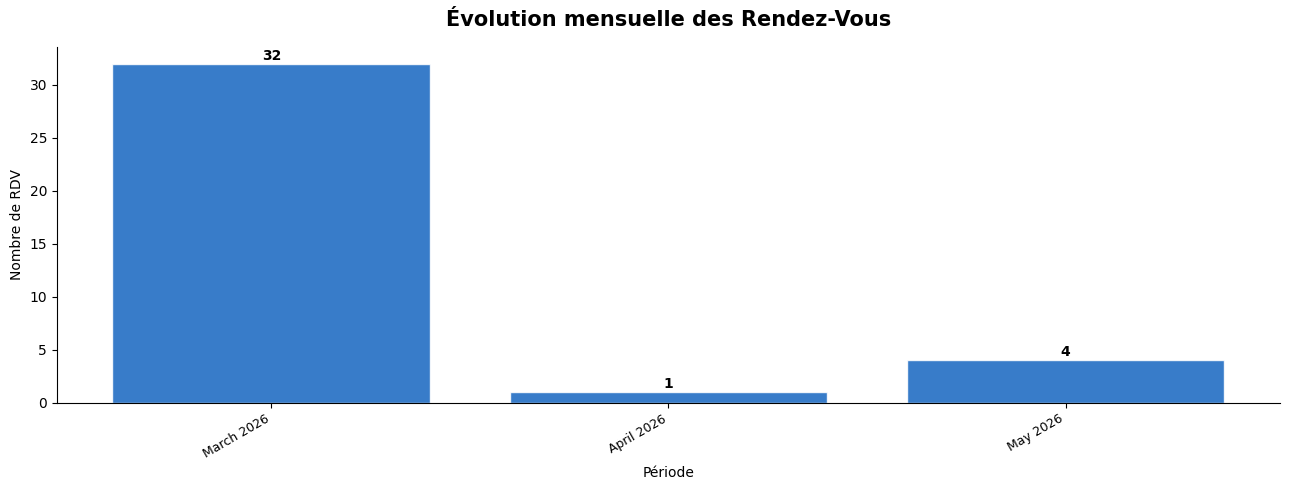

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(len(evolution)), evolution['total'], color=COULEURS[0], alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(evolution)))
ax.set_xticklabels(evolution['periode'], rotation=30, ha='right', fontsize=9)
ax.set_title('Évolution mensuelle des Rendez-Vous', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Nombre de RDV')
ax.set_xlabel('Période')
for i, v in enumerate(evolution['total']):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('viz_evolution_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()

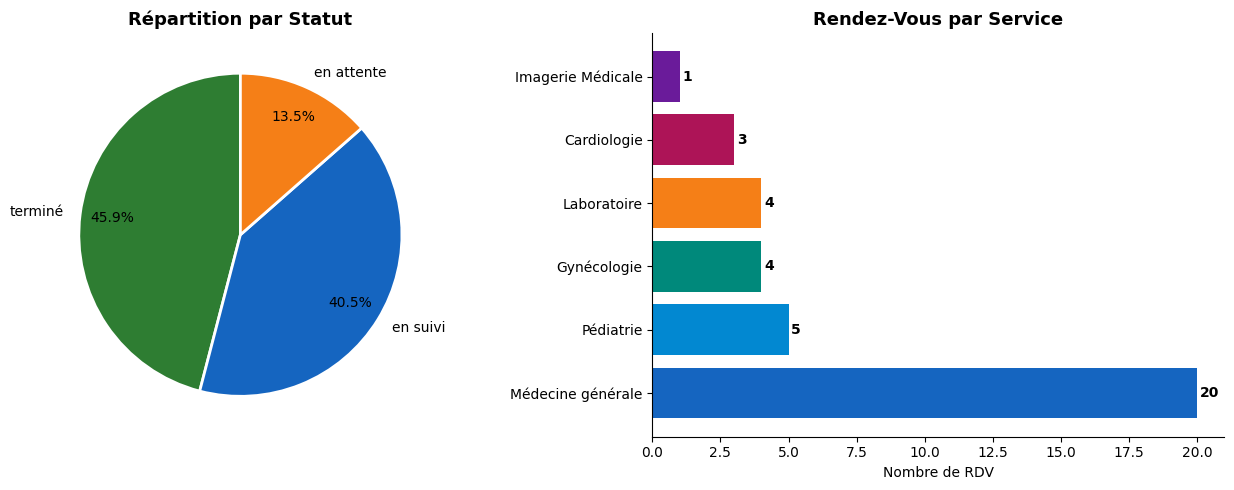

In [15]:
# === VIZ 2 : Répartition par statut ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
statut_counts = fait_rv['statut'].value_counts()
couleurs_statut = ['#2E7D32','#1565C0','#F57F17']
axes[0].pie(statut_counts.values, labels=statut_counts.index, autopct='%1.1f%%',
            colors=couleurs_statut, startangle=90, pctdistance=0.8,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Répartition par Statut', fontsize=13, fontweight='bold')

service_counts = fait_rv['Service'].value_counts()
axes[1].barh(service_counts.index, service_counts.values, color=COULEURS[:len(service_counts)])
axes[1].set_title('Rendez-Vous par Service', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de RDV')
for i, v in enumerate(service_counts.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz_statut_service.png', dpi=150, bbox_inches='tight')
plt.show()

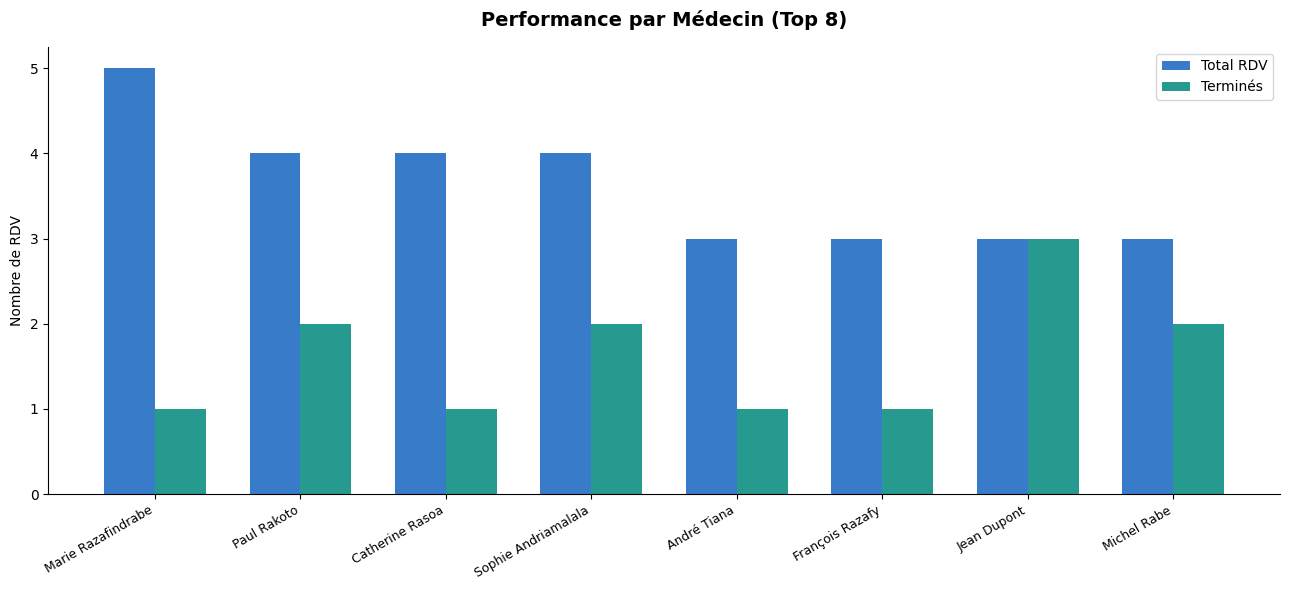

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(kpi_medecin))
width = 0.35
bars1 = ax.bar(x - width/2, kpi_medecin['total'], width, label='Total RDV', color=COULEURS[0], alpha=0.85)
bars2 = ax.bar(x + width/2, kpi_medecin['termines'], width, label='Terminés', color=COULEURS[2], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(kpi_medecin['Medecin'], rotation=30, ha='right', fontsize=9)
ax.set_title('Performance par Médecin (Top 8)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Nombre de RDV')
ax.legend()
plt.tight_layout()
plt.savefig('viz_performance_medecin.png', dpi=150, bbox_inches='tight')
plt.show()

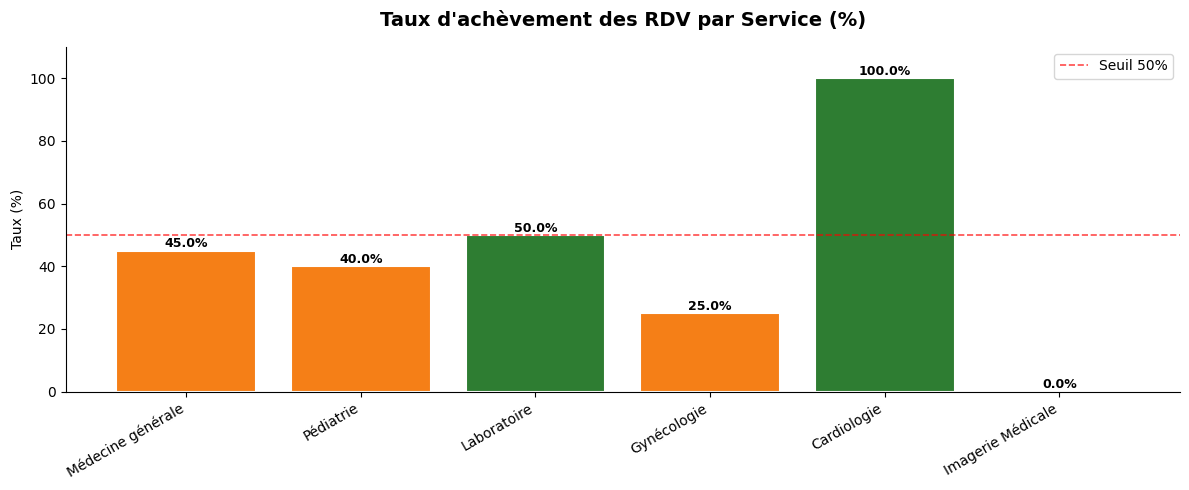


 Toutes les visualisations ont été générées et sauvegardées.


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2E7D32' if t >= 50 else '#F57F17' for t in kpi_service['taux_achev']]
bars = ax.bar(kpi_service['Service'], kpi_service['taux_achev'], color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Seuil 50%')
ax.set_title("Taux d'achèvement des RDV par Service (%)", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Taux (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, kpi_service['taux_achev']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val}%', ha='center', fontweight='bold', fontsize=9)
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz_taux_achevement.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Toutes les visualisations ont été générées et sauvegardées.')